# Neumann BC Test

Fickian (alpha=1) with Neumann (zero-flux) boundary conditions.

This is the identifiable case per Corollary 3.2 of the paper.

### Cell 1: Setup

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # Windows OpenMP workaround

import numpy as np
import torch

from interface import Problem, solve, show_settings
import diagnostics

### Cell 2: Settings

In [3]:
SHARED_CONFIG = {
    "max_iters": 2500,
    "lr_d": 1e-4,
    "wreg_smooth": 1e-5,
    "wreg_scale": 1e-5,
    "smoothness_type": "h1",
    "pert_scale": 0.1,
    "pert_freq": 2.0,
    "scalar_fit_iters": 500,
    "use_scheduler": False,
    "early_burnin": 10000, # effectively off
    "early_patience": 500,
    "early_tol": 1e-4,
    "n_res": 201,
}

DTO_PARTICLE_CONFIG = {
    "wreg_smooth": 1e-2, 
}

PINN_PARTICLE_CONFIG = {
    "wreg_scale":0.1,
    "pretrain_iters": 1000,
    "lr_d":5e-5,
    "lr_lower": 1e-4,
    "w_phys": 10.0,
    "w_jump": 1.0,
    "w_bc": 1.0,
    "use_rff": True,
}

BILO_PARTICLE_CONFIG = {
    "wreg_scale":0.1,   
    "pretrain_iters": 2000,
    "lr_d":5e-5,
    "lr_lower": 1e-4,
    "w_jump": 1.0,
    "w_resgrad": 1e-1,
    "w_bc": 1.0,
    "use_rff": True,
    "early_tol": 1e-8,
    "max_iters": 7500,
}

### Cell 3: Generate Neumann particle data

In [4]:
print("\n--- Neumann Particle Mode Setup ---")
problem_ppp = Problem.synthetic(
    alpha=1.0,  # Fickian (identifiable with Neumann)
    mode="particles",
    d_profile="sinusoidal",
    d_profile_params=(0.1, 0.04, 4.0),
    mu=5.0,
    source_location=0.5,
    b_true=100.0,
    m_obs=1000,
    use_pde_sampling=True,
    bc_type="neumann",
    seed=42,
)

mean_d_true = float(np.mean(problem_ppp.d_true)) if problem_ppp.d_true is not None else None
print(f"u(0) = {problem_ppp.u_true[0]:.3f}, u(1) = {problem_ppp.u_true[-1]:.3f} (should be non-zero)")


--- Neumann Particle Mode Setup ---
[Problem] Particles: n_obs 20026 | m_obs 1000 | ⟨n⟩/obs 20.03 | ⟨D⟩_true: 1.000e-01
u(0) = 3.362, u(1) = 4.024 (should be non-zero)


### Cell 4: DTO (particles)


--- DTO (Neumann particles) ---
[Solve] Method: DTO | α: 1.0 | Mode: particles
[scalar_fit] Starting: d_init=0.083624, mode=particles, max_iters=500
[scalar_fit] iter 0: D=0.183624, loss=-7.597308e+00
[scalar_fit] iter 100: D=0.092452, loss=-7.618441e+00
[scalar_fit] iter 200: D=0.092391, loss=-7.618469e+00
[scalar_fit] iter 300: D=0.092392, loss=-7.618469e+00
[scalar_fit] iter 400: D=0.092392, loss=-7.618469e+00
[scalar_fit] Final: D=0.092392, loss=-7.618469e+00
[DTO] DDI scale: 8.362e-02
[DTO] Scalar fit scale: 9.239e-02
[DTO] Iter 00000 | Ltot: -7.659e+00
  Ldata(ppp): -7.659e+00 | RegSmooth: 6.738e-03 (eff: 6.738e-05) | RegScale: 4.247e-05 (eff: 4.247e-10)
  b0*: 100.13 | int_u_hat: 2.000e-01 | int_u: 2.003e+01 | mean_D: 9.239e-02
[DTO] Iter 00200 | Ltot: -7.744e+00
  Ldata(ppp): -7.746e+00 | RegSmooth: 1.932e-01 (eff: 1.932e-03) | RegScale: 1.945e-04 (eff: 1.945e-09)
  b0*: 100.13 | int_u_hat: 2.000e-01 | int_u: 2.003e+01 | mean_D: 9.579e-02
[DTO] Iter 00400 | Ltot: -7.757e+00
  

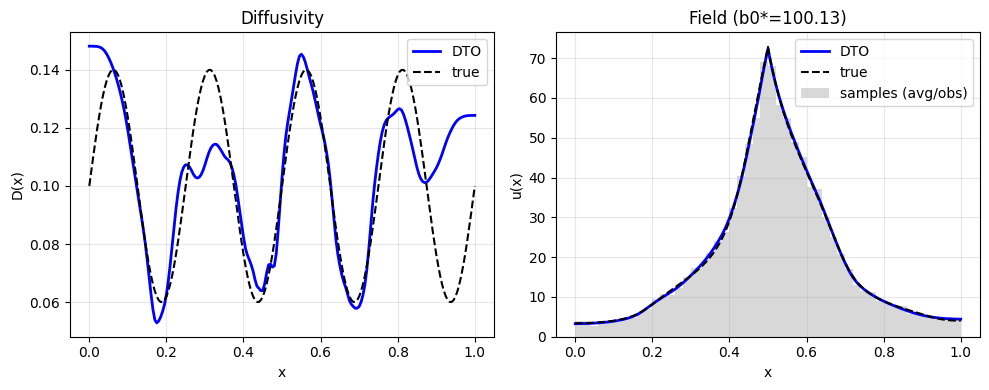

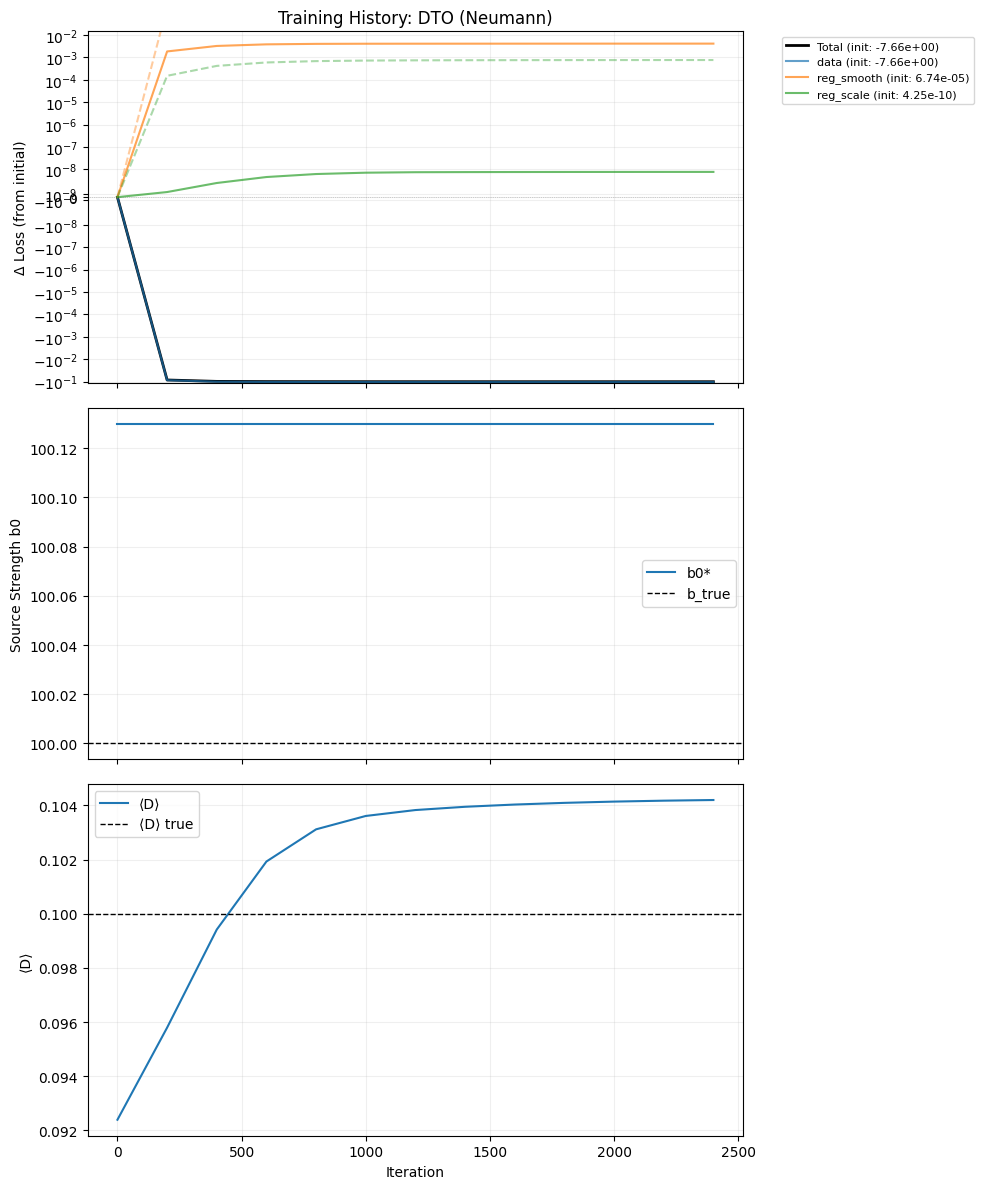

In [5]:
print("\n--- DTO (Neumann particles) ---")
dto_solution = solve(
    problem_ppp,
    method="dto",
    **{**SHARED_CONFIG, **DTO_PARTICLE_CONFIG},
)

dto_metrics = dto_solution.metrics(problem_ppp)
print(f"DTO: D(x) rel error = {dto_metrics['d_rel_error']:.2%}")
dto_solution.plot(problem_ppp)
diagnostics.plot_training_history(
    "DTO (Neumann)",
    dto_solution.history,
    problem_ppp.b_true,
    outdir=None,
    mean_d_true=mean_d_true,
    weights=dto_solution.weights,
)

### Cell 5: PINN (particles)


--- PINN (Neumann particles) ---
[Solve] Method: PINN | α: 1.0 | Mode: particles
[scalar_fit] Starting: d_init=0.083624, mode=particles, max_iters=500
[scalar_fit] iter 0: D=0.183624, loss=-7.597308e+00
[scalar_fit] iter 100: D=0.092452, loss=-7.618441e+00
[scalar_fit] iter 200: D=0.092391, loss=-7.618469e+00
[scalar_fit] iter 300: D=0.092392, loss=-7.618469e+00
[scalar_fit] iter 400: D=0.092392, loss=-7.618469e+00
[scalar_fit] Final: D=0.092392, loss=-7.618469e+00
[PINN] DDI scale: 8.362e-02
[PINN] Scalar fit scale: 9.239e-02
[PINN|pretrain] Iter 00000 | Ltot: 1.281e+02
  Lphys: 1.277e+02 | Lanchor: 3.316e-01
  Lres: 1.267e+01 | Ljump: 1.013e+00 | Lbc: 1.133e-05
  mean_D: 6.682e-01
[PINN|pretrain] Iter 00200 | Ltot: 1.597e+00
  Lphys: 1.045e+00 | Lanchor: 5.524e-01
  Lres: 2.465e-02 | Ljump: 7.265e-04 | Lbc: 7.975e-01
  mean_D: 8.355e-01
[PINN|pretrain] Iter 00400 | Ltot: 1.044e+00
  Lphys: 5.487e-01 | Lanchor: 4.953e-01
  Lres: 5.697e-03 | Ljump: 3.559e-03 | Lbc: 4.882e-01
  mean_D:

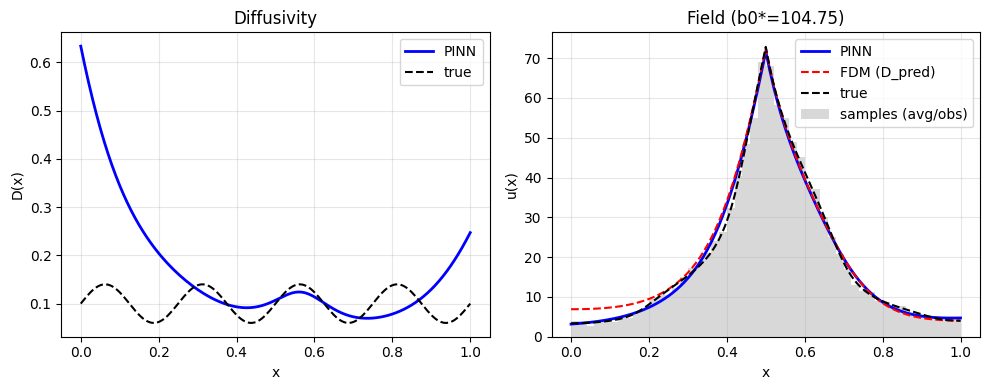

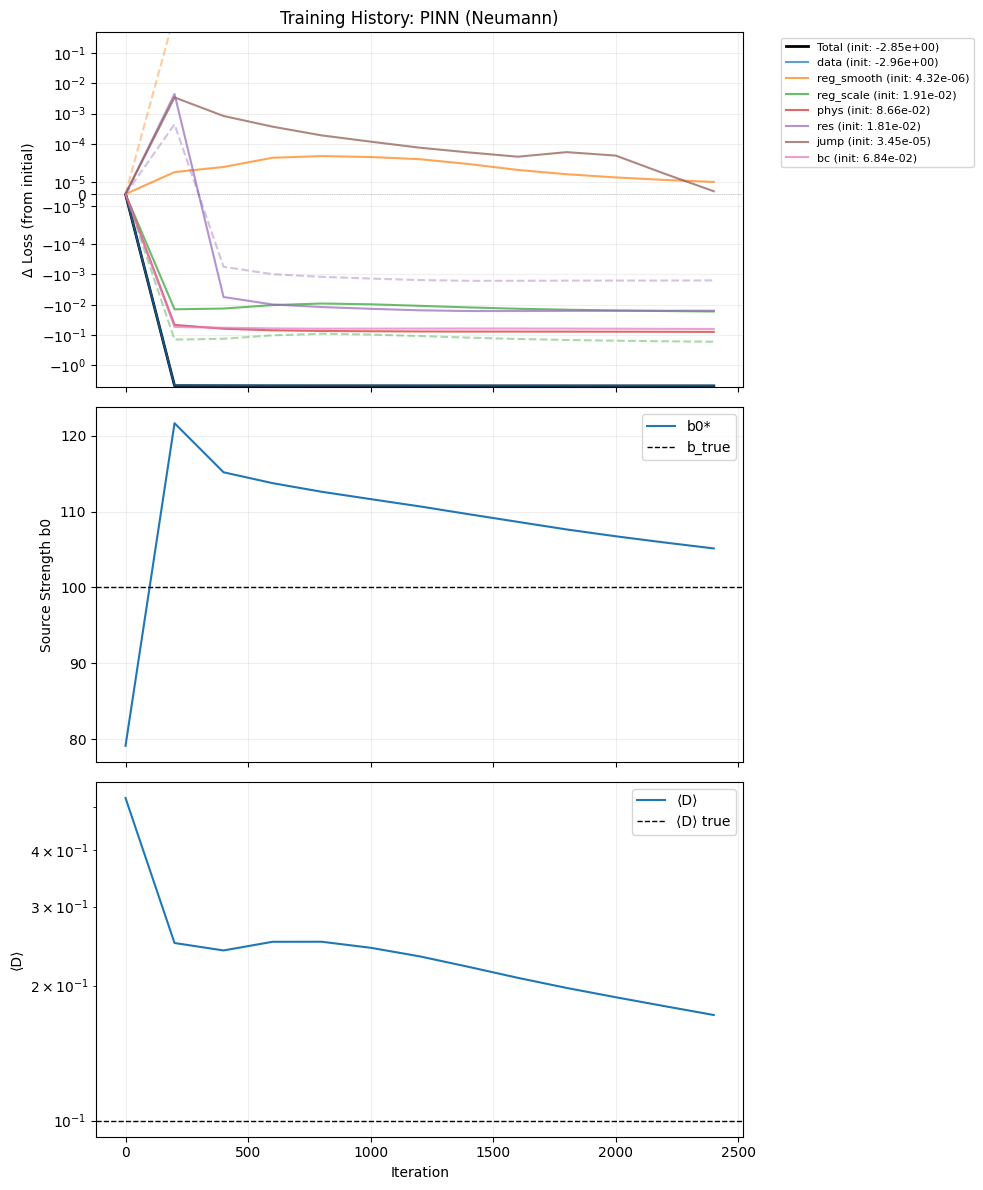

In [6]:
print("\n--- PINN (Neumann particles) ---")
pinn_solution = solve(
    problem_ppp,
    method="pinn",
    **{**SHARED_CONFIG, **PINN_PARTICLE_CONFIG},
)

pinn_metrics = pinn_solution.metrics(problem_ppp)
print(f"PINN: D(x) rel error = {pinn_metrics['d_rel_error']:.2%}")
pinn_solution.plot(problem_ppp)
diagnostics.plot_training_history(
    "PINN (Neumann)",
    pinn_solution.history,
    problem_ppp.b_true,
    outdir=None,
    mean_d_true=mean_d_true,
    weights=pinn_solution.weights,
)

### Cell 6: BiLO (particles)


--- BiLO (Neumann particles) ---
[Solve] Method: BILO | α: 1.0 | Mode: particles
[scalar_fit] Starting: d_init=0.083624, mode=particles, max_iters=500
[scalar_fit] iter 0: D=0.183624, loss=-7.597308e+00
[scalar_fit] iter 100: D=0.092452, loss=-7.618441e+00
[scalar_fit] iter 200: D=0.092391, loss=-7.618469e+00
[scalar_fit] iter 300: D=0.092392, loss=-7.618469e+00
[scalar_fit] iter 400: D=0.092392, loss=-7.618469e+00
[scalar_fit] Final: D=0.092392, loss=-7.618469e+00
[BiLO] DDI scale: 8.362e-02
[BiLO] Scalar fit scale: 9.239e-02
[BiLO|pretrain] Iter 00000 | Ltot: 1.267e+01
  Lanchor: 4.326e-01 | Llower: 1.198e+01 | Lsup: 2.482e-01
  Lres: 1.099e+01 | Ljump: 9.971e-01 | Lrgrad: 5.075e-03 | Ljump_rgrad: 1.333e-06 | Lbc: 1.065e-04
  mean_D: 7.471e-01
[BiLO|pretrain] Iter 00200 | Ltot: 8.974e-01
  Lanchor: 2.690e-02 | Llower: 8.423e-01 | Lsup: 2.825e-02
  Lres: 7.128e-02 | Ljump: 4.136e-01 | Lrgrad: 3.291e-02 | Ljump_rgrad: 1.928e-01 | Lbc: 3.348e-01
  mean_D: 2.451e-01
[BiLO|pretrain] Iter

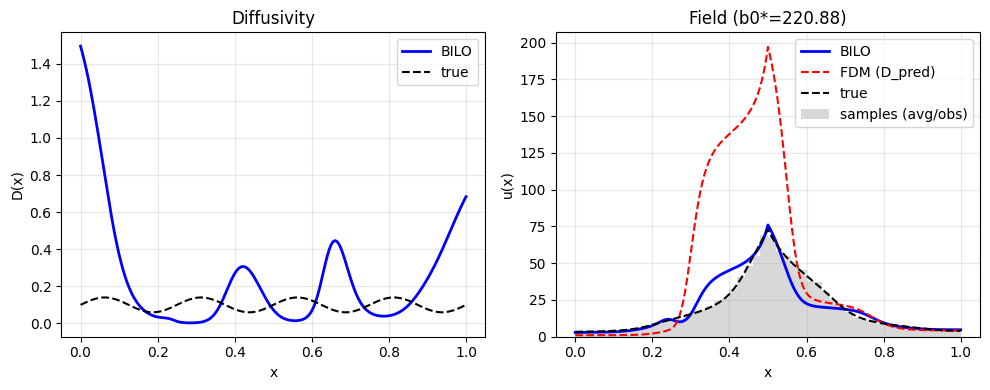

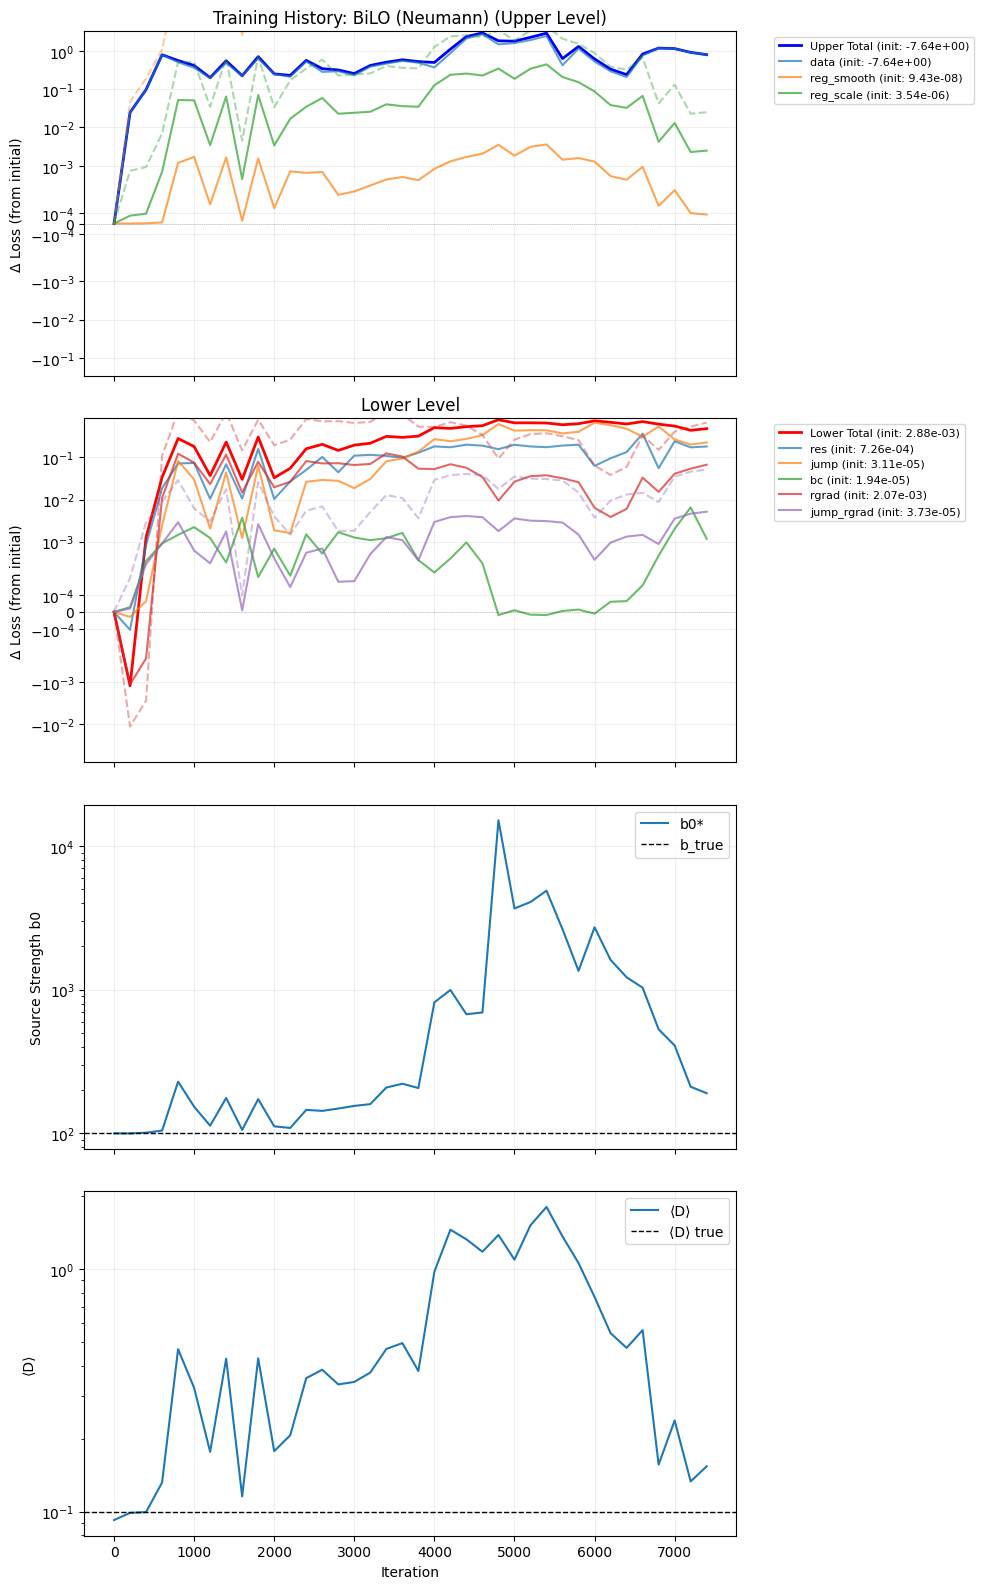

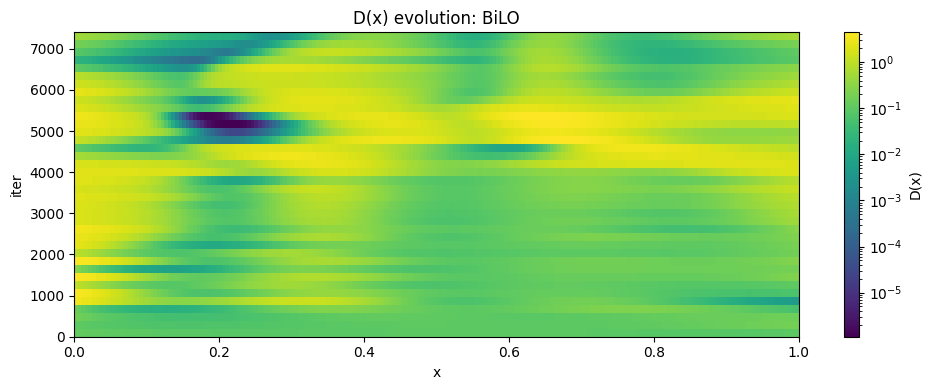

In [7]:
print("\n--- BiLO (Neumann particles) ---")
bilo_solution = solve(
    problem_ppp,
    method="bilo",
    **{**SHARED_CONFIG, **BILO_PARTICLE_CONFIG},
)

bilo_metrics = bilo_solution.metrics(problem_ppp)
print(f"BiLO: D(x) rel error = {bilo_metrics['d_rel_error']:.2%}")
bilo_solution.plot(problem_ppp)
diagnostics.plot_training_history(
    "BiLO (Neumann)",
    bilo_solution.history,
    problem_ppp.b_true,
    outdir=None,
    mean_d_true=mean_d_true,
    weights=bilo_solution.weights,
)

diagnostics.plot_d_evolution(
    "BiLO",
    bilo_solution.history,
    bilo_solution.x_res.detach().cpu().numpy().reshape(-1),
    outdir=None,
    mean_d_true=mean_d_true,
)
